In [1]:
import pandas as pd

In [4]:
df=pd.read_excel(r'Students-data-trial.xlsx',sheet_name='Sheet1')

In [5]:
df

,Student ID,Board,School,Standard,Subject,Marks,Grade,Stream,Group
0,S12_001,GSEB,School A,Std. 8,Maths,81,A2,General,NaN
1,S12_001,GSEB,School A,Std. 8,Science,34,D,General,NaN
2,S12_001,GSEB,School A,Std. 8,English,42,C2,General,NaN
3,S12_001,GSEB,School A,Std. 8,Social Science,37,D,General,NaN
4,S12_001,GSEB,School A,Std. 8,Gujarati/Hindi,84,A2,General,NaN
...,...,...,...,...,...,...,...,...,...
385,S10_010,GSEB,School B,Std. 9,Sanskrit/Computer,82,A2,General,NaN
386,S10_010,GSEB,School B,Std. 10,Maths,100,A1,General,NaN
387,S10_010,GSEB,School B,Std. 10,Science,39,D,General,NaN
388,S10_010,GSEB,School B,Std. 10,Gujarati/Hindi,67,B2,General,NaN


In [11]:
df.columns

Index(['Student ID', 'Board', 'School', 'Standard', 'Subject', 'Marks',
       'Grade', 'Stream', 'Group'],
      dtype='object')

In [12]:
df_grouped = df.groupby(['School', 'Standard'])['Student ID'].nunique()
df_grouped

School    Standard
School A  Std. 10     10
          Std. 11     10
          Std. 12     10
          Std. 8      10
          Std. 9      10
School B  Std. 10     10
          Std. 8      10
          Std. 9      10
Name: Student ID, dtype: int64

🔹 Dataset Info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 390 entries, 0 to 389
Data columns (total 9 columns):
 #   Column      Non-Null Count  Dtype 
---  ------      --------------  ----- 
 0   Student ID  390 non-null    object
 1   Board       390 non-null    object
 2   School      390 non-null    object
 3   Standard    390 non-null    object
 4   Subject     390 non-null    object
 5   Marks       390 non-null    int64 
 6   Grade       390 non-null    object
 7   Stream      390 non-null    object
 8   Group       36 non-null     object
dtypes: int64(1), object(8)
memory usage: 27.6+ KB
None

🔹 First 5 Rows:
  Student ID Board    School Standard         Subject  Marks Grade   Stream  \
0    S12_001  GSEB  School A   Std. 8           Maths     81    A2  General   
1    S12_001  GSEB  School A   Std. 8         Science     34     D  General   
2    S12_001  GSEB  School A   Std. 8         English     42    C2  General   
3    S12_001  GSEB  School A   Std. 8  Social Scien

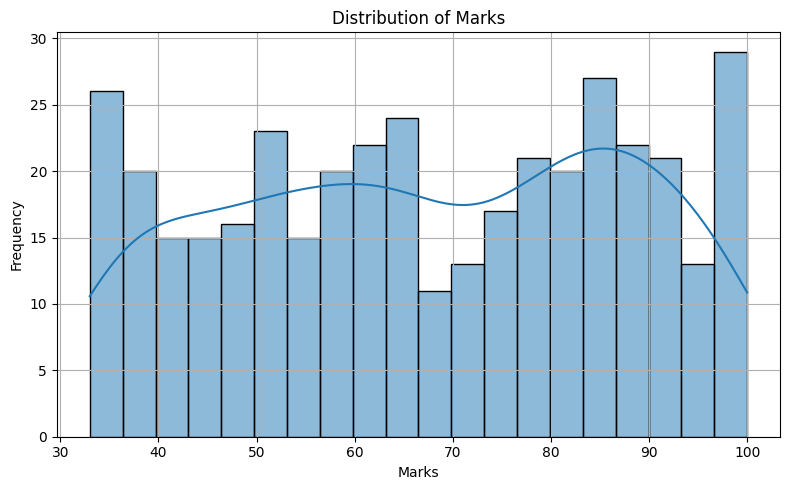

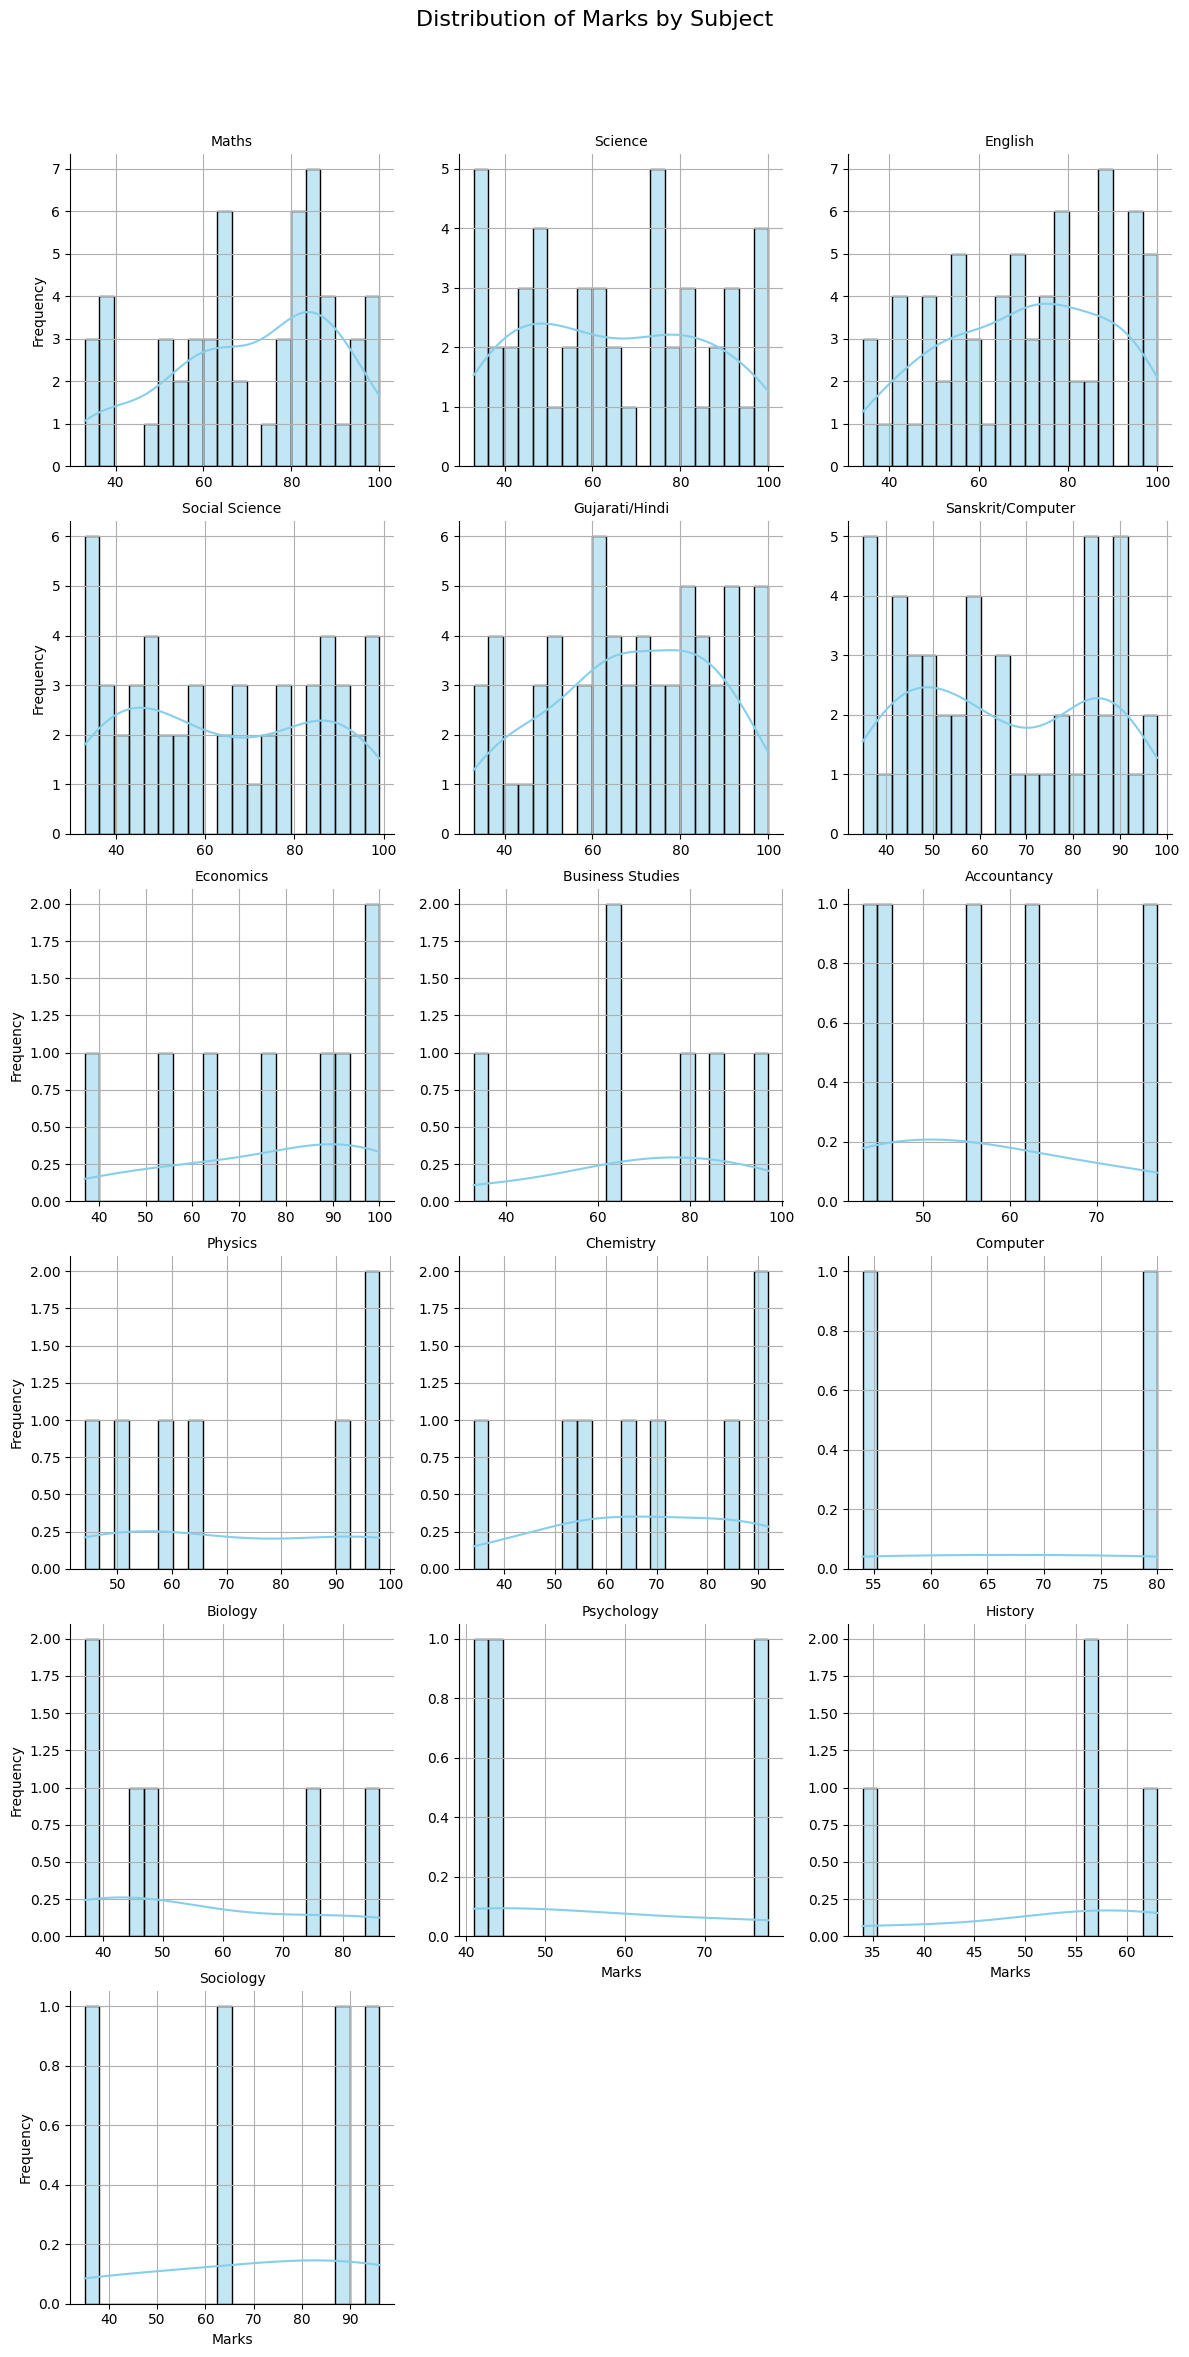

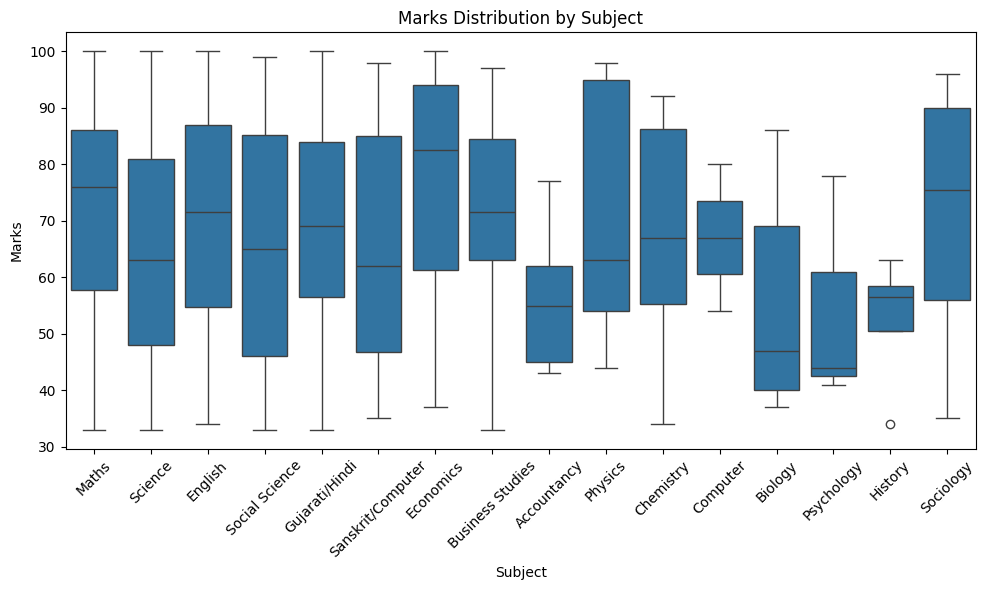

C:\Users\vvagh\AppData\Local\Temp\ipykernel_26652\1548266432.py:56: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=avg_board.index, y=avg_board.values, palette='viridis')


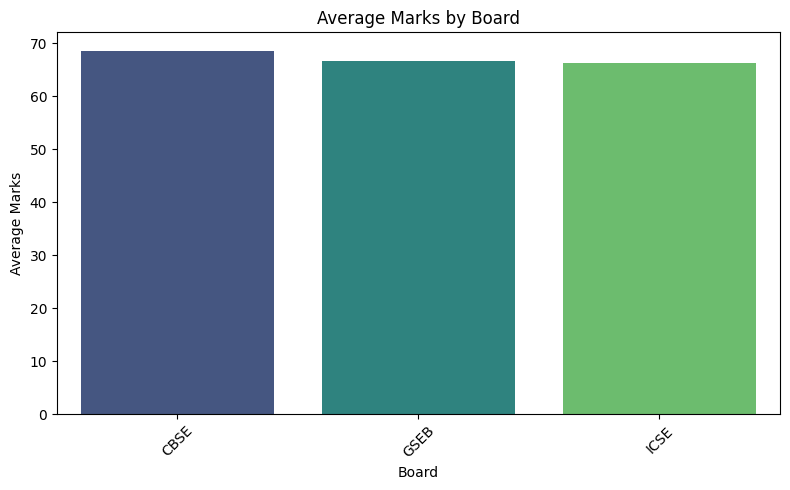

C:\Users\vvagh\AppData\Local\Temp\ipykernel_26652\1548266432.py:67: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=avg_stream.index, y=avg_stream.values, palette='coolwarm')


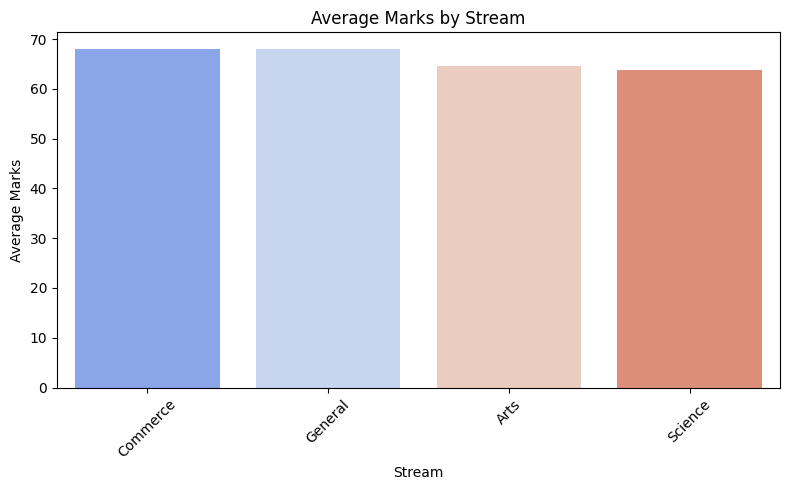

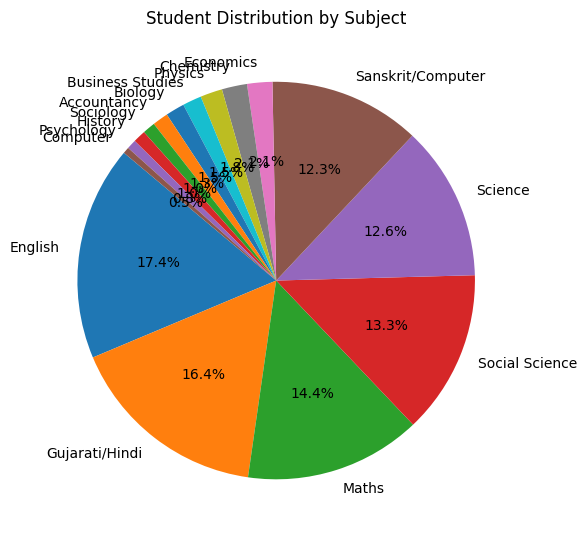

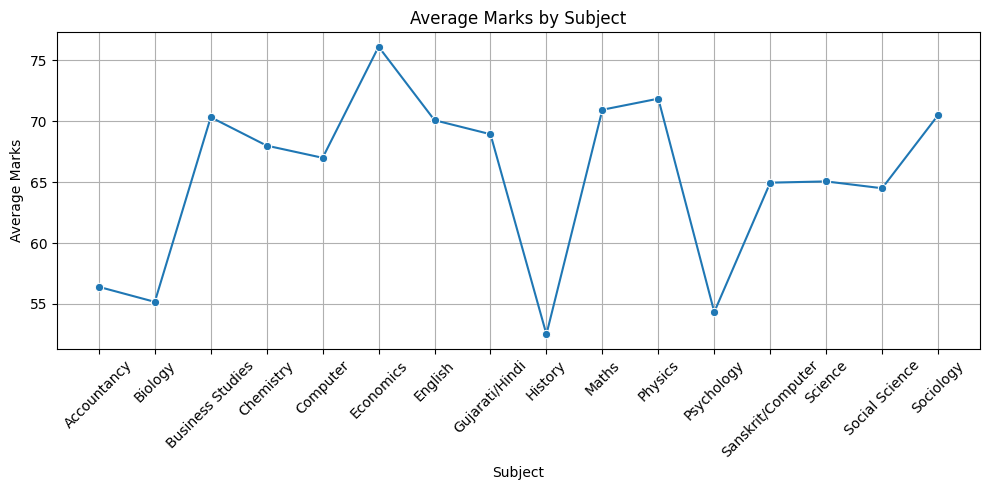

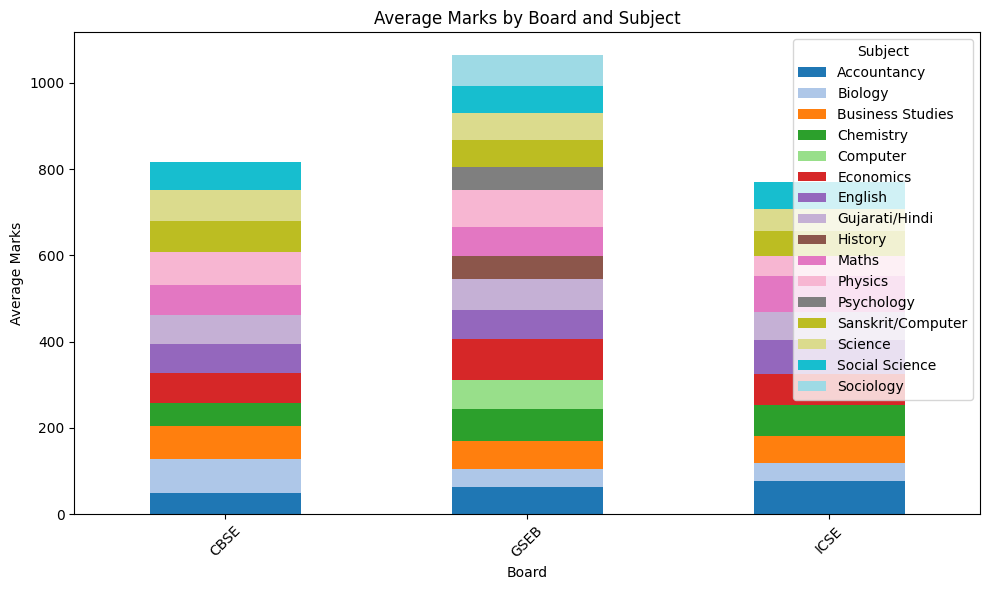

In [4]:
# eda_script.py

import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Load the data
df = pd.read_excel(r'Students-data-trial.xlsx',sheet_name='Sheet1')  # Replace with your actual CSV file name

# Display basic information
print("🔹 Dataset Info:")
print(df.info())

print("\n🔹 First 5 Rows:")
print(df.head())

print("\n🔹 Summary Statistics:")
print(df.describe(include='all'))

# Check for missing values
print("\n🔹 Missing Values:")
print(df.isnull().sum())

# Distribution of Marks
plt.figure(figsize=(8, 5))
sns.histplot(df['Marks'], bins=20, kde=True)
plt.title('Distribution of Marks')
plt.xlabel('Marks')
plt.ylabel('Frequency')
plt.grid(True)
plt.tight_layout()
plt.show()
# Distribution of Marks by Subject
g = sns.FacetGrid(df, col='Subject', col_wrap=3, height=4, sharex=False, sharey=False)
g.map_dataframe(sns.histplot, x='Marks', bins=20, kde=True, color='skyblue')
g.set_titles('{col_name}')
g.set_axis_labels('Marks', 'Frequency')
for ax in g.axes.flat:
    ax.grid(True)
g.fig.suptitle('Distribution of Marks by Subject', fontsize=16)
g.fig.tight_layout()
g.fig.subplots_adjust(top=0.92)
plt.show()

# Marks by Subject
plt.figure(figsize=(10, 6))
sns.boxplot(data=df, x='Subject', y='Marks')
plt.title('Marks Distribution by Subject')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

# Average Marks by Board
plt.figure(figsize=(8, 5))
avg_board = df.groupby('Board')['Marks'].mean().sort_values(ascending=False)
sns.barplot(x=avg_board.index, y=avg_board.values, palette='viridis')
plt.title('Average Marks by Board')
plt.ylabel('Average Marks')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

# Average Marks by Stream (if present)
if 'Stream' in df.columns:
    plt.figure(figsize=(8, 5))
    avg_stream = df.groupby('Stream')['Marks'].mean().sort_values(ascending=False)
    sns.barplot(x=avg_stream.index, y=avg_stream.values, palette='coolwarm')
    plt.title('Average Marks by Stream')
    plt.ylabel('Average Marks')
    plt.xticks(rotation=45)
    plt.tight_layout()
    plt.show()

# Pie chart: Distribution of Students by Subject
subject_counts = df['Subject'].value_counts()
plt.figure(figsize=(6, 6))
plt.pie(subject_counts, labels=subject_counts.index, autopct='%1.1f%%', startangle=140)
plt.title('Student Distribution by Subject')
plt.tight_layout()
plt.show()

# Line Chart: Average Marks by Subject
avg_marks_subject = df.groupby('Subject')['Marks'].mean()
plt.figure(figsize=(10, 5))
sns.lineplot(x=avg_marks_subject.index, y=avg_marks_subject.values, marker='o')
plt.title('Average Marks by Subject')
plt.ylabel('Average Marks')
plt.xticks(rotation=45)
plt.grid(True)
plt.tight_layout()
plt.show()

# Stacked Bar Chart: Marks by Board and Subject (if meaningful)
if 'Board' in df.columns and 'Subject' in df.columns:
    pivot_table = df.pivot_table(index='Board', columns='Subject', values='Marks', aggfunc='mean')
    pivot_table.plot(kind='bar', stacked=True, figsize=(10, 6), colormap='tab20')
    plt.title('Average Marks by Board and Subject')
    plt.ylabel('Average Marks')
    plt.xticks(rotation=45)
    plt.tight_layout()
    plt.show()


c:\Users\vvagh\miniconda3\envs\stenv\Lib\site-packages\sklearn\cluster\_kmeans.py:1426: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=2.
  warnings.warn(


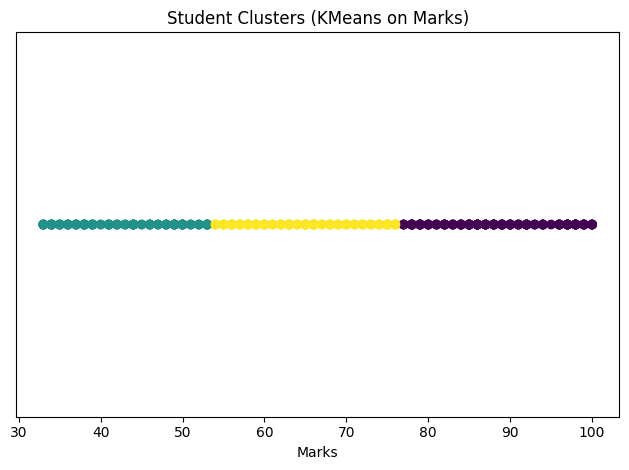

In [9]:
from sklearn.decomposition import PCA
from sklearn.cluster import KMeans

# Select numeric features
data = df.select_dtypes(include='number').dropna()

if data.shape[1] < 2:
	# Only one numeric feature, cluster and plot in 1D
	kmeans = KMeans(n_clusters=3, random_state=0)
	labels = kmeans.fit_predict(data)
	plt.scatter(data.iloc[:, 0], [0]*len(data), c=labels, cmap='viridis')
	plt.title('Student Clusters (KMeans on Marks)')
	plt.xlabel(data.columns[0])
	plt.yticks([])
	plt.tight_layout()
	plt.show()
else:
	# Reduce to 2D
	pca = PCA(n_components=2)
	pca_data = pca.fit_transform(data)
	# Cluster
	kmeans = KMeans(n_clusters=3, random_state=0)
	labels = kmeans.fit_predict(pca_data)
	# Plot
	plt.scatter(pca_data[:, 0], pca_data[:, 1], c=labels, cmap='viridis')
	plt.title('Student Clusters (PCA + KMeans)')
	plt.xlabel('PC1')
	plt.ylabel('PC2')
	plt.tight_layout()
	plt.show()


c:\Users\vvagh\miniconda3\envs\stenv\Lib\site-packages\sklearn\cluster\_kmeans.py:1426: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=2.
  warnings.warn(


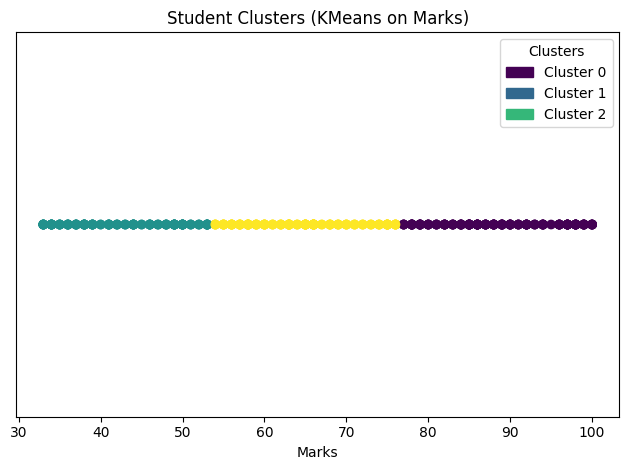

In [10]:
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from sklearn.decomposition import PCA
from sklearn.cluster import KMeans

# Select numeric features
data = df.select_dtypes(include='number').dropna()

if data.shape[1] < 2:
    # Only one numeric feature, cluster and plot in 1D
    kmeans = KMeans(n_clusters=3, random_state=0)
    labels = kmeans.fit_predict(data)
    plt.scatter(data.iloc[:, 0], [0]*len(data), c=labels, cmap='viridis')
    plt.title('Student Clusters (KMeans on Marks)')
    plt.xlabel(data.columns[0])
    plt.yticks([])
    legend_handles = [mpatches.Patch(color=plt.cm.viridis(i/3), label=f'Cluster {i}') for i in range(3)]
    plt.legend(handles=legend_handles, title='Clusters')
    plt.tight_layout()
    plt.show()
else:
    # Reduce to 2D
    pca = PCA(n_components=2)
    pca_data = pca.fit_transform(data)
    # Cluster
    kmeans = KMeans(n_clusters=3, random_state=0)
    labels = kmeans.fit_predict(pca_data)
    # Plot
    plt.scatter(pca_data[:, 0], pca_data[:, 1], c=labels, cmap='viridis')
    plt.title('Student Clusters (PCA + KMeans)')
    plt.xlabel('PC1')
    plt.ylabel('PC2')
    legend_handles = [mpatches.Patch(color=plt.cm.viridis(i/3), label=f'Cluster {i}') for i in range(3)]
    plt.legend(handles=legend_handles, title='Clusters')
    plt.tight_layout()
    plt.show()
